📂 Upload CSV file


Saving Language Detection.csv to Language Detection (2).csv

Dataset Loaded ✔
                                                Text Language
0   Nature, in the broadest sense, is the natural...  English
1  "Nature" can refer to the phenomena of the phy...  English
2  The study of nature is a large, if not the onl...  English
3  Although humans are part of nature, human acti...  English
4  [1] The word nature is borrowed from the Old F...  English

Total Clean Samples: 10271


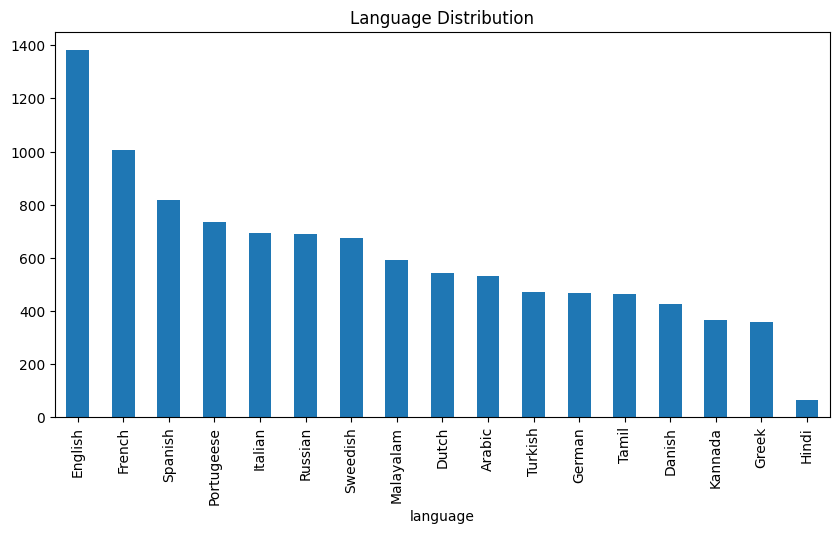


Languages Found:
['Arabic', 'Danish', 'Dutch', 'English', 'French', 'German', 'Greek', 'Hindi', 'Italian', 'Kannada', 'Malayalam', 'Portugeese', 'Russian', 'Spanish', 'Sweedish', 'Tamil', 'Turkish']
SVM Accuracy: 98.69%


In [ ]:
# ==========================
# LANGUAGE DETECTION FULL FIXED PROJECT
# COLAB + STREAMLIT READY
# ==========================

!pip install -q scikit-learn pandas numpy joblib matplotlib

import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# ==========================
# STEP 1: UPLOAD CSV
# ==========================
print("📂 Upload CSV file")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name, engine="python")

print("\nDataset Loaded ✔")
print(df.head())

# ==========================
# STEP 2: CLEAN COLUMN ISSUES (IMPORTANT FIX)
# ==========================
df = df.iloc[:, :2]
df.columns = ["text", "language"]

# remove empty / broken rows
df = df.dropna()
df = df.drop_duplicates()

# strip spaces
df["text"] = df["text"].astype(str)
df["language"] = df["language"].astype(str)

# ==========================
# STEP 3: CLEAN TEXT (IMPORTANT FIX)
# ==========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)   # remove symbols
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)

print("\nTotal Clean Samples:", len(df))

# ==========================
# STEP 4: EDA
# ==========================
plt.figure(figsize=(10,5))
df["language"].value_counts().plot(kind="bar")
plt.title("Language Distribution")
plt.show()

# ==========================
# STEP 5: LABEL ENCODING
# ==========================
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["language"])

print("\nLanguages Found:")
print(list(encoder.classes_))

# ==========================
# STEP 6: TRAIN TEST SPLIT
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# ==========================
# STEP 7: TF-IDF (FINAL FIX)
# ==========================
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2,4),
    max_features=50000,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ==========================
# STEP 8: MODELS (COMPARE)
# ==========================
models = {
    "SVM": LinearSVC(),
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced")
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name} Accuracy: {round(acc*100,2)}%")

# ==========================
# STEP 9: BEST MODEL
# ==========================
best_name = max(results, key=results.get)
best_model = models[best_name]

print("\n🏆 BEST MODEL:", best_name)

# ==========================
# STEP 10: SAVE MODELS
# ==========================
joblib.dump(best_model, "language_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print("\n✅ MODELS SAVED")

# ==========================
# STEP 11: CLEAN PREDICTION FUNCTION (FIXED)
# ==========================
def predict_language(text):
    text = clean_text(text)

    if len(text.strip()) < 2:
        return "⚠ Enter more text"

    vec = vectorizer.transform([text])
    pred = best_model.predict(vec)[0]

    return encoder.inverse_transform([pred])[0]

# ==========================
# STEP 12: LIVE TEST (FIXED)
# ==========================
print("\n===== LIVE TEST MODE =====")
print("Type 'exit' to stop")

while True:
    text = input("Enter text: ")

    if text.lower() == "exit":
        print("Exited 🚀")
        break

    print("👉 Language:", predict_language(text))